In [6]:
import sys, os
sys.path.append(os.path.abspath('..'))

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.model_selection import train_test_split

from src.data_processing import clean_text
from src.features import Vocabulary, texts_to_sequences, TextDataset
from torch.utils.data import DataLoader

df = pd.read_csv("../data/processed/dataset_kaggle_daigt_processed.csv", sep=";")

label_map = {label: i for i, label in enumerate(df['Label'].unique())}
idx_to_label = {v: k for k, v in label_map.items()}
NUM_CLASSES = len(label_map)
print(f"Classes ({NUM_CLASSES}): {label_map}")

df['label_id']   = df['Label'].map(label_map)
df['text_clean'] = df['Text'].apply(clean_text)

X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    df['text_clean'], df['label_id'], test_size=0.2, random_state=42, stratify=df['label_id']
)

Classes (5): {'Anthropic': 0, 'Google': 1, 'Human': 2, 'Meta': 3, 'OpenAI': 4}


In [7]:
import torch.nn as nn

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct = 0.0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y_batch)
        correct    += (logits.argmax(dim=1) == y_batch).sum().item()
    n = len(loader.dataset)
    return total_loss / n, correct / n

def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct = 0.0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            total_loss += loss.item() * len(y_batch)
            correct    += (logits.argmax(dim=1) == y_batch).sum().item()
    n = len(loader.dataset)
    return total_loss / n, correct / n

def train_model(model, train_loader, val_loader, epochs, lr=1e-3, verbose=True):
    model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr
    )
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
        vl_loss, vl_acc = eval_epoch(model,  val_loader,   criterion)
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(vl_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(vl_acc)
        if verbose and (epoch % 5 == 0 or epoch == 1):
            print(f"Epoch {epoch:>3}/{epochs} | Loss Treino: {tr_loss:.4f} | Loss Val: {vl_loss:.4f} | "
                  f"Acc Treino: {tr_acc:.3f} | Acc Val: {vl_acc:.3f}")
    return history

Device: cpu


In [30]:
import time
import pandas as pd
from IPython.display import display
from src.hyperopt import build_grid
from src.models_pytorch.cnn1d import CNN1DClassifier

MAX_LEN = 32
BATCH_SIZE = 64

param_grid_cnn = {
    'vocab_size': [1000, 2000, 2500],
    'embedding_dim': [50, 100],
    'n_filters': [32, 64, 128],
    'filter_sizes': [[2, 3], [1, 2, 3]],
    'epochs': [30, 60] 
}

resultados_cnn = []

print("=== A Iniciar Grid Search: CNN1D em PyTorch ===")
for params in build_grid(param_grid_cnn):
    print(f"\nA testar: {params}")
    inicio = time.time()

    vocab = Vocabulary(max_words=params['vocab_size'])
    vocab.fit(X_train_raw.tolist())

    X_train_seq = texts_to_sequences(X_train_raw.tolist(), vocab, max_len=MAX_LEN)
    X_val_seq   = texts_to_sequences(X_val_raw.tolist(),   vocab, max_len=MAX_LEN)

    train_loader = DataLoader(TextDataset(X_train_seq, y_train.values), batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(TextDataset(X_val_seq,   y_val.values),   batch_size=BATCH_SIZE, shuffle=False)

    model = CNN1DClassifier(
        vocab_size=len(vocab), 
        embedding_dim=params['embedding_dim'], 
        n_filters=params['n_filters'], 
        filter_sizes=params['filter_sizes'], 
        output_dim=NUM_CLASSES, 
        dropout=0.3
    )

    history = train_model(model, train_loader, val_loader, epochs=params['epochs'], lr=1e-3, verbose=False)
    
    val_acc_final = history['val_acc'][-1]
    val_loss_final = history['val_loss'][-1]
    tempo_gasto = time.time() - inicio
    
    resultados_cnn.append({
        'Vocab Size': params['vocab_size'],
        'Embed Dim': params['embedding_dim'],
        'N Filters': params['n_filters'],
        'Filter Sizes': str(params['filter_sizes']),
        'Epochs': params['epochs'],
        'Val Accuracy': val_acc_final,
        'Val Loss': val_loss_final,
        'Tempo (s)': round(tempo_gasto, 1)
    })
    print(f" -> Val Acc: {val_acc_final:.4f} | Val Loss: {val_loss_final:.4f} | Tempo: {tempo_gasto:.1f}s")

df_grid_cnn = pd.DataFrame(resultados_cnn).sort_values(by='Val Accuracy', ascending=False)
display(df_grid_cnn)

=== A Iniciar Grid Search: CNN1D em PyTorch ===

A testar: {'vocab_size': 1000, 'embedding_dim': 50, 'n_filters': 32, 'filter_sizes': [2, 3], 'epochs': 30}
 -> Val Acc: 0.8531 | Val Loss: 0.4430 | Tempo: 2.0s

A testar: {'vocab_size': 1000, 'embedding_dim': 50, 'n_filters': 32, 'filter_sizes': [2, 3], 'epochs': 60}
 -> Val Acc: 0.8687 | Val Loss: 0.4593 | Tempo: 3.9s

A testar: {'vocab_size': 1000, 'embedding_dim': 50, 'n_filters': 32, 'filter_sizes': [1, 2, 3], 'epochs': 30}
 -> Val Acc: 0.8492 | Val Loss: 0.4421 | Tempo: 2.6s

A testar: {'vocab_size': 1000, 'embedding_dim': 50, 'n_filters': 32, 'filter_sizes': [1, 2, 3], 'epochs': 60}
 -> Val Acc: 0.8648 | Val Loss: 0.4840 | Tempo: 4.8s

A testar: {'vocab_size': 1000, 'embedding_dim': 50, 'n_filters': 64, 'filter_sizes': [2, 3], 'epochs': 30}
 -> Val Acc: 0.8557 | Val Loss: 0.4213 | Tempo: 2.3s

A testar: {'vocab_size': 1000, 'embedding_dim': 50, 'n_filters': 64, 'filter_sizes': [2, 3], 'epochs': 60}
 -> Val Acc: 0.8804 | Val Loss: 0

,Vocab Size,Embed Dim,N Filters,Filter Sizes,Epochs,Val Accuracy,Val Loss,Tempo (s)
20,1000,100,128,"[2, 3]",30,0.894668,0.414676,3.3
7,1000,50,64,"[1, 2, 3]",60,0.892068,0.414234,5.3
23,1000,100,128,"[1, 2, 3]",60,0.890767,0.520702,8.2
45,2000,100,128,"[2, 3]",60,0.888166,0.455009,6.7
43,2000,100,64,"[1, 2, 3]",60,0.888166,0.490668,6.6
...,...,...,...,...,...,...,...,...
0,1000,50,32,"[2, 3]",30,0.853056,0.442974,2.0
48,2500,50,32,"[2, 3]",30,0.853056,0.417587,2.0
2,1000,50,32,"[1, 2, 3]",30,0.849155,0.442080,2.6
28,2000,50,64,"[2, 3]",30,0.849155,0.440726,2.1


=== A Treinar a melhor CNN1D ===
Epoch   1/15 | Loss Treino: 1.2881 | Loss Val: 0.8386 | Acc Treino: 0.478 | Acc Val: 0.750
Epoch   5/15 | Loss Treino: 0.4250 | Loss Val: 0.4419 | Acc Treino: 0.859 | Acc Val: 0.863
Epoch  10/15 | Loss Treino: 0.2117 | Loss Val: 0.3778 | Acc Treino: 0.931 | Acc Val: 0.880
Epoch  15/15 | Loss Treino: 0.1119 | Loss Val: 0.3720 | Acc Treino: 0.967 | Acc Val: 0.889


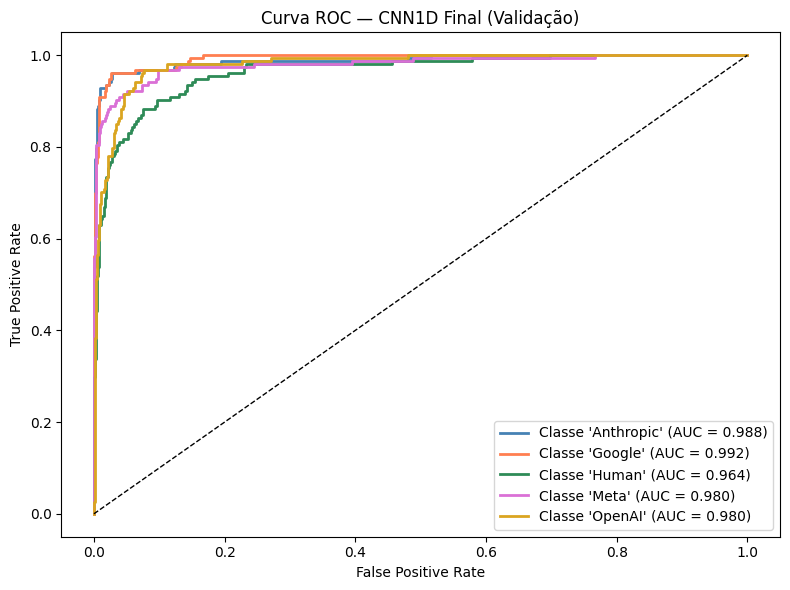


Sucesso! Model weights (.pth) e Vocabulário (.pkl) guardados.


In [110]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import torch.nn.functional as F

print("=== A Treinar a melhor CNN1D ===")

vocab_final = Vocabulary(max_words=1000)
vocab_final.fit(X_train_raw.tolist())

X_train_seq = texts_to_sequences(X_train_raw.tolist(), vocab_final, max_len=MAX_LEN)
X_val_seq   = texts_to_sequences(X_val_raw.tolist(),   vocab_final, max_len=MAX_LEN)

train_loader = DataLoader(TextDataset(X_train_seq, y_train.values), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TextDataset(X_val_seq,   y_val.values),   batch_size=BATCH_SIZE, shuffle=False)

model = CNN1DClassifier(
    vocab_size=len(vocab_final), 
    embedding_dim=100,
    n_filters=128,
    filter_sizes=[1, 2, 3],
    output_dim=NUM_CLASSES,
    dropout=0.45
).to(DEVICE)

history_final = train_model(model, train_loader, val_loader, epochs=15, lr=1e-3, verbose=True)

model.eval()
all_probs, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in val_loader:
        logits = model(X_batch.to(DEVICE))
        probs  = F.softmax(logits, dim=1).cpu().numpy()
        all_probs.append(probs)
        all_labels.append(y_batch.numpy())

all_probs  = np.vstack(all_probs)
all_labels = np.concatenate(all_labels)

classes    = list(range(NUM_CLASSES))
labels_bin = label_binarize(all_labels, classes=classes)

plt.figure(figsize=(8, 6))
colors = ['steelblue', 'coral', 'seagreen', 'orchid', 'goldenrod']

for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(labels_bin[:, i], all_probs[:, i])
    roc_auc     = auc(fpr, tpr)
    class_name  = idx_to_label[i]
    plt.plot(fpr, tpr, color=colors[i % len(colors)], lw=2,
             label=f"Classe '{class_name}' (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Curva ROC — CNN1D Final (Validação)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

import os
os.makedirs("../saved_models", exist_ok=True)

vocab_final.save("../saved_models/vocab_cnn.pkl")
torch.save(model.state_dict(), "../saved_models/cnn1d_final.pth")

print("\nSucesso! Model weights (.pth) e Vocabulário (.pkl) guardados.")

In [111]:
print("Melhor Val Accuracy CNN1D:", max(history_final["val_acc"]))
print("Melhor Val Loss CNN1D:", min(history_final["val_loss"]))

Melhor Val Accuracy CNN1D: 0.8894668400520156
Melhor Val Loss CNN1D: 0.36730391027403436
